 Важные моменты:
Testnet для тестирования: Всегда тестируйте сначала на тестовой сети

Rate Limits: Bybit имеет лимиты запросов (обычно 50-100 в минуту)

Время сервера: Все временные метки в миллисекундах

Account Type: Используйте правильный тип счета:

UNIFIED - унифицированный счет

CONTRACT - фьючерсный счет

SPOT - спотовый счет

#### api keys

In [1]:
# real
# API_KEY = 'xlW2BRB2iqKNkrbTKm'
# API_SECRET = 'HzZdpFL6Liuc8qdxMu3WrnfvwJWdIZyLgXCI'

In [21]:
# testnet
API_KEY = 'WjyWI4adh41aeD2yhr'
API_SECRET = 'Vj1AGtYPUygPNvqyjNX9xImu7lMKjPlvXyDX'

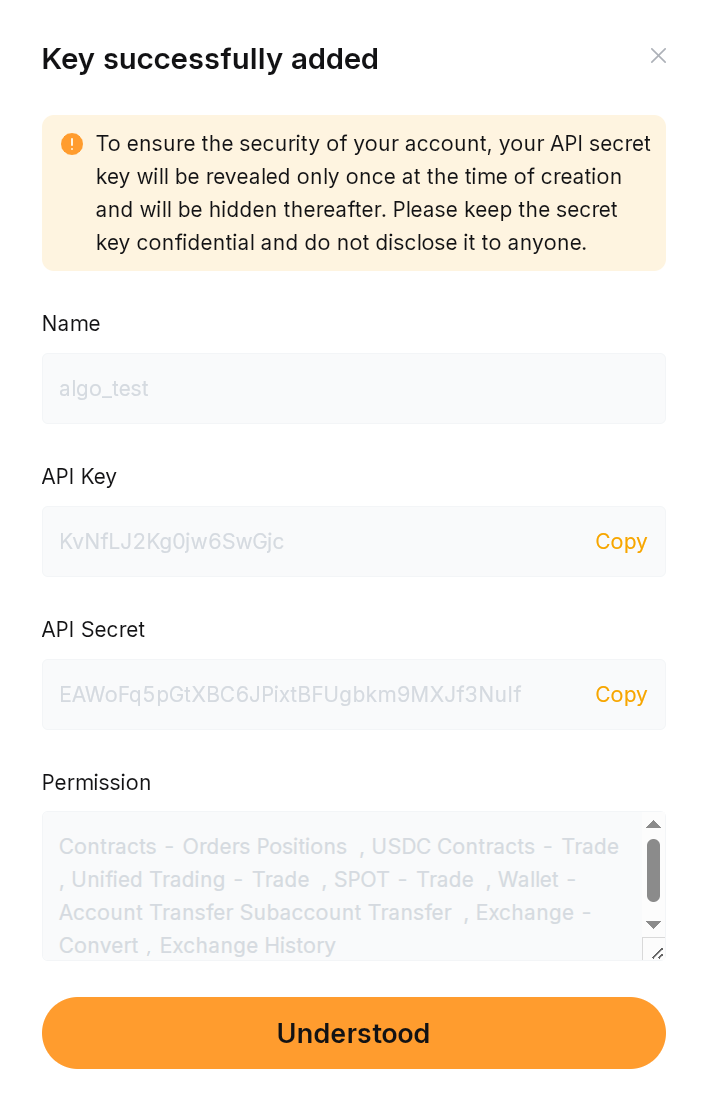

In [22]:
# pip install pybit
# pip install --upgrade certifi

#### Библиотеки для работы

In [67]:
from pybit.unified_trading import HTTP
import json
from typing import Literal, Optional, Dict, Any
import pandas as pd
from datetime import datetime
import numpy as np
import time
import requests
from tabulate import tabulate

#### Инициализация сессии

In [45]:
session = HTTP(
    testnet=False,
    api_key=API_KEY,
    api_secret=API_SECRET,
    demo=True
)

#### Получение информации о стакане

In [46]:
def get_orderbook(
    session: HTTP,
    symbol: str = "BTCUSDT",
    market_type: Literal["spot", "linear"] = "spot",
    limit: int = 10
) -> Optional[dict]:
    """
    Получение и красивое отображение стакана котировок (orderbook)
    
    Args:
        session: HTTP сессия pybit
        symbol: Торговый инструмент (например "BTCUSDT")
        market_type: Тип рынка ("spot" или "linear" для фьючерсов)
        limit: Количество уровней в стакане (1, 25, 50, 100, 200)
    """
    
    try:
        # Выбор категории в зависимости от типа рынка
        category = market_type
        
        # Получение данных стакана
        response = session.get_orderbook(
            category=category,
            symbol=symbol,
            limit=limit
        )
        
        if response.get("retCode") == 0:
            orderbook = response["result"]
            
            # Красивый вывод информации
            print("=" * 80)
            print(f"📊 СТАКАН КОТИРОВОК {symbol}")
            print(f"📅 Время: {datetime.fromtimestamp(int(orderbook['ts']) / 1000).strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"📈 Тип рынка: {market_type.upper()}")
            print(f"📋 Глубина стакана: {limit} уровней")
            print(f"🔄 Последнее обновление: {orderbook['ts']}")
            print("=" * 80)
            
            # Преобразование в DataFrame для красивого отображения
            bids_df = pd.DataFrame(orderbook['b'], columns=['Price', 'Size'])
            asks_df = pd.DataFrame(orderbook['a'], columns=['Price', 'Size'])
            
            # Конвертация в числовые значения
            bids_df[['Price', 'Size']] = bids_df[['Price', 'Size']].astype(float)
            asks_df[['Price', 'Size']] = asks_df[['Price', 'Size']].astype(float)
            
            # Расчет объемов в USD (приблизительно)
            bids_df['Value (USD)'] = bids_df['Price'] * bids_df['Size']
            asks_df['Value (USD)'] = asks_df['Price'] * asks_df['Size']
            
            # Суммарные объемы
            total_bid_volume = bids_df['Size'].sum()
            total_ask_volume = asks_df['Size'].sum()
            total_bid_value = bids_df['Value (USD)'].sum()
            total_ask_value = asks_df['Value (USD)'].sum()
            
            print("\n📥 ПОКУПКИ (BIDS):")
            print("-" * 60)
            print(bids_df.head(10).to_string(index=False))
            print(f"\n📊 Общий объем покупок: {total_bid_volume:.4f} {symbol.replace('USDT', '')}")
            print(f"💰 Общая стоимость: ${total_bid_value:,.2f}")
            
            print("\n📤 ПРОДАЖИ (ASKS):")
            print("-" * 60)
            print(asks_df.head(10).to_string(index=False))
            print(f"\n📊 Общий объем продаж: {total_ask_volume:.4f} {symbol.replace('USDT', '')}")
            print(f"💰 Общая стоимость: ${total_ask_value:,.2f}")
            
            # Лучшие цены
            best_bid = float(orderbook['bids'][0][0]) if orderbook['bids'] else 0
            best_ask = float(orderbook['asks'][0][0]) if orderbook['asks'] else 0
            
            print("\n🎯 ЛУЧШИЕ ЦЕНЫ:")
            print("-" * 60)
            print(f"🏷️  Лучшая цена покупки: {best_bid:,.2f}")
            print(f"🏷️  Лучшая цена продажи: {best_ask:,.2f}")
            print(f"📐 Спред: {best_ask - best_bid:,.2f} ({(best_ask - best_bid) / best_bid * 100:.4f}%)")
            
            print("=" * 80)
            
            return orderbook
            
        else:
            print(f"❌ Ошибка получения стакана: {response.get('retMsg')}")
            return None
            
    except Exception as e:
        print(f"❌ Исключение при получении стакана: {e}")
        return None

- Получение фьючерсного стакана BTCUSDT

In [47]:
print("\n📌 ФЬЮЧЕРСНЫЙ РЫНОК")
spot_orderbook = get_orderbook(
    session=session,
    symbol="BTCUSDT",
    market_type="linear",
    limit=5
)


📌 ФЬЮЧЕРСНЫЙ РЫНОК
📊 СТАКАН КОТИРОВОК BTCUSDT
📅 Время: 2026-03-14 17:59:42
📈 Тип рынка: LINEAR
📋 Глубина стакана: 5 уровней
🔄 Последнее обновление: 1773500382023

📥 ПОКУПКИ (BIDS):
------------------------------------------------------------
  Price  Size  Value (USD)
70537.1 0.809   57064.5139
70537.0 0.001      70.5370
70536.0 0.041    2891.9760
70535.7 0.001      70.5357
70535.4 0.001      70.5354

📊 Общий объем покупок: 0.8530 BTC
💰 Общая стоимость: $60,168.10

📤 ПРОДАЖИ (ASKS):
------------------------------------------------------------
  Price  Size  Value (USD)
70537.2 4.085  288144.4620
70537.4 0.001      70.5374
70538.3 0.002     141.0766
70538.4 0.002     141.0768
70538.6 0.001      70.5386

📊 Общий объем продаж: 4.0910 BTC
💰 Общая стоимость: $288,567.69
❌ Исключение при получении стакана: 'bids'


#### Получение информации о счете

In [8]:
# account_type: Literal["UNIFIED", "SPOT", "FUND", "CONTRACT", "OPTION"] = "UNIFIED",

In [58]:
# Получение баланса для Единого торгового аккаунта (UNIFIED)
balance_info = session.get_wallet_balance(accountType="UNIFIED")

In [63]:
def print_balance_summary(balance_info):
    """Быстрый вывод сводки по балансу"""
    if balance_info.get('retCode') != 0:
        print(f"❌ Ошибка: {balance_info.get('retMsg')}")
        return
    
    account = balance_info['result']['list'][0]
    
    print("\n" + "="*50)
    print("📊 СВОДКА БАЛАНСА")
    print("="*50)
    print(f"💰 Капитал: ${float(account['totalEquity']):,.2f}")
    print(f"💳 Доступно: ${float(account['totalAvailableBalance']):,.2f}")
    print(f"📈 PnL: ${float(account['totalPerpUPL']):,.2f}")
    
    # Топ монет
    coins = sorted(account['coin'], 
                  key=lambda x: float(x['usdValue']), 
                  reverse=True)[:3]
    
    print("\n💎 Топ монет:")
    for coin in coins:
        if float(coin['usdValue']) > 0:
            print(f"   {coin['coin']}: ${float(coin['usdValue']):,.2f}")

In [64]:
print_balance_summary(balance_info)


📊 СВОДКА БАЛАНСА
💰 Капитал: $172,667.46
💳 Доступно: $99,917.64
📈 PnL: $0.00

💎 Топ монет:
   BTC: $70,676.28
   USDC: $49,998.80
   USDT: $49,918.84


#### Текущие открытые ордера на исполнение

In [72]:
def get_open_orders_info(session: HTTP, category: str = "spot", symbol: Optional[str] = None) -> Dict[str, Any]:
    """
    Получение информации об открытых ордерах
    
    Args:
        session: Сессия Bybit
        category: Тип ордеров (spot, linear, inverse, option)
        symbol: Символ пары (опционально)
    
    Returns:
        Dict с информацией об ордерах
    """
    try:
        params = {"category": category}
        if symbol:
            params["symbol"] = symbol
            
        response = session.get_open_orders(**params)
        
        if response.get('retCode') == 0:
            return response.get('result', {})
        else:
            print(f"❌ Ошибка получения ордеров: {response.get('retMsg', 'Неизвестная ошибка')}")
            return {}
            
    except Exception as e:
        print(f"❌ Исключение при получении ордеров: {e}")
        return {}

In [81]:
def print_open_orders_summary(session: HTTP, category: str = "spot") -> None:
    """
    Компактный вывод открытых ордеров
    
    Args:
        session: Сессия Bybit
        category: Тип ордеров
    """
    orders_info = get_open_orders_info(session, category, symbol='BTCUSDT')
    orders_list = orders_info.get('list', [])
    
    if not orders_list:
        print("📭 Нет открытых ордеров")
        return
    
    print("\n" + "="*80)
    print("📋 ОТКРЫТЫЕ ОРДЕРА")
    print("="*80)
    
    for order in orders_list:
        side = order.get('side', 'N/A')
        side_emoji = "🟢" if side.upper() == "BUY" else "🔴"
        
        symbol = order.get('symbol', 'N/A')
        order_type = order.get('orderType', 'N/A')
        price = float(order.get('price', 0))
        qty = float(order.get('qty', 0))
        leaves_qty = float(order.get('leavesQty', 0))
        
        print(f"{side_emoji} {symbol} | {order_type} | Цена: ${price:,.4f} | "
              f"{qty:,.4f} (Осталось: {leaves_qty:,.4f})")
    
    print(f"\n📊 Всего ордеров: {len(orders_list)}")
    print("="*80)


In [93]:
# Компактный вывод
print("\n📊 КОМПАКТНЫЙ ВЫВОД:")
print_open_orders_summary(session, category="linear")


📊 КОМПАКТНЫЙ ВЫВОД:

📋 ОТКРЫТЫЕ ОРДЕРА
🔴 BTCUSDT | Market | Цена: $0.0000 | 1.0000 (Осталось: 1.0000)
🔴 BTCUSDT | Market | Цена: $0.0000 | 1.0000 (Осталось: 1.0000)

📊 Всего ордеров: 2


#### Отправка заявки market

In [87]:
# Упрощенная версия только для фьючерсов
def place_futures_trade(
    session: HTTP,
    symbol: str,
    side: str,
    amount_usdt: float,
    stop_loss_price: Optional[float] = None,
    take_profit_price: Optional[float] = None
) -> dict:
    """
    Размещение фьючерсного ордера на Bybit
    
    Args:
        session: Сессия Bybit
        symbol: Торговая пара (например, "BTCUSDT")
        side: Направление ("buy" или "sell")
        amount_usdt: Сумма в USDT
        stop_loss_price: Цена стоп-лосс
        take_profit_price: Цена тейк-профит
    
    Returns:
        dict: Результат выполнения
    """
    
    # Получаем текущую цену
    ticker = session.get_tickers(category="linear", symbol=symbol)
    if ticker['retCode'] != 0:
        return {"error": "Не удалось получить цену"}
    
    current_price = float(ticker['result']['list'][0]['lastPrice'])
    
    # Получаем информацию о контракте
    contract_info = session.get_instruments_info(category="linear", symbol=symbol)
    if contract_info['retCode'] != 0:
        return {"error": "Не удалось получить информацию о контракте"}
    
    # Определяем размер контракта для разных пар
    contract_map = {
        "BTCUSDT": 0.001,  # 1 контракт = 0.001 BTC
        "ETHUSDT": 0.01,   # 1 контракт = 0.01 ETH
        "SOLUSDT": 0.1,    # 1 контракт = 0.1 SOL
        "XRPUSDT": 1.0,    # 1 контракт = 1 XRP
    }
    
    # Размер контракта для данной пары
    contract_size = contract_map.get(symbol, 0.001)  # По умолчанию 0.001
    
    # Конвертируем USDT в количество контрактов
    # amount_usdt / current_price = количество монет
    # количество монет / contract_size = количество контрактов
    coin_amount = amount_usdt / current_price
    contracts = int(coin_amount / contract_size)
    
    if contracts <= 0:
        return {"error": f"Слишком маленькая сумма. Минимум: {contract_size * current_price} USDT"}
    
    print(f"Конвертация: {amount_usdt} USDT -> {coin_amount:.6f} монет -> {contracts} контрактов")
    
    # Размещаем ордер
    order = session.place_order(
        category="linear",
        symbol=symbol,
        side=side.capitalize(),
        orderType="Market",
        qty=str(contracts),
        timeInForce="GTC",
        positionIdx=0
    )
    
    if order['retCode'] != 0:
        return {"error": f"Ошибка: {order['retMsg']}"}
    
    # Устанавливаем SL/TP
    if stop_loss_price or take_profit_price:
        tp_sl = {}
        if take_profit_price:
            tp_sl["takeProfit"] = str(take_profit_price)
        if stop_loss_price:
            tp_sl["stopLoss"] = str(stop_loss_price)
        
        session.set_trading_stop(
            category="linear",
            symbol=symbol,
            positionIdx=0,
            **tp_sl
        )
    
    return {
        "success": True,
        "order_id": order['result']['orderId'],
        "contracts": contracts,
        "coin_amount": coin_amount,
        "price": current_price,
        "total_usdt": contracts * contract_size * current_price
    }

In [91]:
# Пример для BTC фьючерсов
result = place_futures_trade(
    session=session,
    symbol="BTCUSDT",
    side="buy",
    amount_usdt=100,  # 100 USDT
    stop_loss_price=70000,
    take_profit_price=71000
)

Конвертация: 100 USDT -> 0.001417 монет -> 1 контрактов


In [92]:
if "error" in result:
    print(f"Ошибка: {result['error']}")
else:
    print(f"✅ Ордер размещен!")
    print(f"   ID: {result['order_id']}")
    print(f"   Контрактов: {result['contracts']}")
    print(f"   BTC: {result['coin_amount']:.6f}")
    print(f"   Цена: ${result['price']:.2f}")
    print(f"   Объем: ${result['total_usdt']:.2f}")

✅ Ордер размещен!
   ID: be2f0fcb-bb18-457a-94fa-3a7c07912735
   Контрактов: 1
   BTC: 0.001417
   Цена: $70551.50
   Объем: $70.55


#### Закрытие открытой позиции

In [105]:
def close_position(
    session: HTTP,
    symbol: str,
    category: str = "linear",
    position_idx: int = 0
) -> dict:
    """
    Закрытие открытой позиции на Bybit
    
    Args:
        session: Сессия Bybit
        symbol: Торговая пара (например, "BTCUSDT")
        category: Тип рынка ("linear" для USDT фьючерсов, "inverse" для инверсных)
        position_idx: Индекс позиции (0 - однонаправленный режим, 1 - long, 2 - short)
    
    Returns:
        dict: Результат выполнения
    """
    
    # Получаем информацию о текущей позиции
    positions = session.get_positions(
        category=category,
        symbol=symbol,
        settleCoin="USDT"
    )
    
    if positions['retCode'] != 0:
        return {"error": f"Не удалось получить информацию о позиции: {positions['retMsg']}"}
    
    # Ищем открытую позицию
    position_list = positions['result']['list']
    open_position = None
    
    for pos in position_list:
        if float(pos.get('size', 0)) > 0:
            open_position = pos
            break
    
    if not open_position:
        return {"error": f"Нет открытой позиции по {symbol}"}
    
    # Определяем сторону для закрытия
    current_side = open_position['side']
    close_side = "Sell" if current_side == "Buy" else "Buy"
    
    # Получаем размер позиции
    position_size = float(open_position['size'])
    
    print(f"Закрытие позиции: {symbol} {current_side} {position_size}")
    
    # Закрываем позицию рыночным ордером
    order = session.place_order(
        category=category,
        symbol=symbol,
        side=close_side,
        orderType="Market",
        qty=str(position_size),
        positionIdx=position_idx,
        timeInForce="GTC",
        reduceOnly=True  # Важно! Только уменьшение позиции
    )
    
    if order['retCode'] != 0:
        return {"error": f"Ошибка закрытия позиции: {order['retMsg']}"}
    
    # Возвращаем результат
    return {
        "success": True,
        "symbol": symbol,
        "side_closed": current_side,
        "size": position_size,
        "entry_price": float(open_position.get('avgPrice', 0)),
        "pnl": float(open_position.get('unrealisedPnl', 0)),
        "order_id": order['result']['orderId']
    }

In [106]:
# Закрываем позицию по BTC
result = close_position(
    session=session,
    symbol="BTCUSDT",
    category="linear"
)

Закрытие позиции: BTCUSDT Buy 1.0


In [107]:
 if "error" in result:
    print(f"❌ Ошибка: {result['error']}")
else:
    print(f"✅ Позиция закрыта:")
    print(f"   Пара: {result['symbol']}")
    print(f"   Сторона: {result['side_closed']}")
    print(f"   Размер: {result['size']}")
    print(f"   PnL: ${result['pnl']:.2f}")
    print(f"   Order ID: {result['order_id']}")

✅ Позиция закрыта:
   Пара: BTCUSDT
   Сторона: Buy
   Размер: 1.0
   PnL: $-34.96
   Order ID: 3479ce05-f4f5-4e0b-9577-e2599620ae22
